### 导入相应模块
### 为了方便观察输出，忽略部分warning
### 设定随机性种子并使用确定性算法

In [16]:
import os
import shutil
import numpy as np
import paddle
import paddle.nn as nn
import paddle.vision.transforms as transforms
from paddle.io import Dataset, DataLoader
from paddle.vision.datasets import DatasetFolder
from paddle.optimizer import Adam
# from paddle.metric import Accuracy # Accuracy metric can be calculated in the evaluate function
import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split # Not used in the provided snippet
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings # 导入 warnings 模块

# 忽略特定的 UserWarning
warnings.filterwarnings("ignore", message="When training, we now always track global mean and variance.")

# 设定随机数种子
seed = 42
paddle.seed(seed)
np.random.seed(seed)
# 使用确定性算法
paddle.set_flags({'FLAGS_cudnn_deterministic': True})
paddle.set_flags({'FLAGS_benchmark': False})  # 禁用benchmark


### 对原始数据集进行划分

- 如果此板块被注释说明此数据集已完成划分
- 仅需运行一次即可

In [20]:


# # 0. 数据集划分
# def split_dataset(src_dir, dst_dir, train_ratio=0.6, val_ratio=0.25, test_ratio=0.15):
#     if not os.path.exists(dst_dir):
#         os.makedirs(dst_dir)
#     for split in ['train', 'val', 'test']:
#         for cls in os.listdir(src_dir):
#             os.makedirs(os.path.join(dst_dir, split, cls), exist_ok=True)
#     for cls in os.listdir(src_dir):
#         cls_path = os.path.join(src_dir, cls)
#         if not os.path.isdir(cls_path):
#             continue
#         images = os.listdir(cls_path)
#         train_imgs, temp_imgs = train_test_split(images, test_size=(1-train_ratio), random_state=42)
#         val_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_ratio/(test_ratio+val_ratio), random_state=42)
#         for img in train_imgs:
#             shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'train', cls, img))
#         for img in val_imgs:
#             shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'val', cls, img))
#         for img in test_imgs:
#             shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'test', cls, img))

# # 只需运行一次
# split_dataset('./balanced_images', './dataset')



### 数据集增强与加载

In [3]:
# 1. 数据集增强与加载
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # 随机水平翻转
    transforms.RandomRotation(15),               # 随机旋转15度
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2,
                           hue=0.1),             # 颜色抖动
    transforms.Resize((96, 96)),               # 重设图片大小
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 类别 2，3，4 易混淆，增加其样本权重
class_weights = paddle.to_tensor([1.0, 1.2, 1.2, 1.1, 1.0])
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 保证数据集路径正确
try:
    train_dataset = DatasetFolder('./dataset/train', transform=transform)
    val_dataset = DatasetFolder('./dataset/val', transform=transform)
    test_dataset = DatasetFolder('./dataset/test', transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4 if paddle.is_compiled_with_cuda() else 0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4 if paddle.is_compiled_with_cuda() else 0) # Typically shuffle=False for validation
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4 if paddle.is_compiled_with_cuda() else 0)
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure your dataset is correctly placed in './dataset/train', './dataset/val', and './dataset/test'")
    print("Each of these directories should contain subdirectories for each class.")
    exit()



c:\Users\22245\.conda\envs\paddle_env_new\lib\site-packages\paddle\io\reader.py:429: UserWarning: DataLoader with multi-process mode is not supported on MacOs and Windows currently. Please use signle-process mode with num_workers = 0 instead
  warnings.warn(


### 定义残差块与ResNet模型

In [17]:
#  2.实现基本残差块
class BasicBlock(nn.Layer):
    expansion = 1 # ResNet18/34中，输入输出通道数在块内不扩展

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # 第一个卷积层
        self.conv1 = nn.Conv2D(in_channels, out_channels, kernel_size=5, stride=stride, padding=2, bias_attr=False)
        self.bn1 = nn.BatchNorm2D(out_channels)
        self.relu = nn.ReLU()
        # 第二个卷积层
        self.conv2 = nn.Conv2D(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias_attr=False)
        self.bn2 = nn.BatchNorm2D(out_channels)
        
        self.downsample = downsample # 用于处理快捷连接维度不匹配的情况
        self.stride = stride

    def forward(self, x):
        identity = x # 保存输入，即快捷连接的起点

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None: # 如果存在下采样层（通常是维度不匹配时）
            identity = self.downsample(x)

        out += identity # 核心：将卷积输出与原始输入（或经过下采样）相加
        out = self.relu(out)

        return out

# 3. 定义 ResNetMyself 模型

class MySimpleResNet(nn.Layer):
    def __init__(self, block, layers_cfg, num_classes=5): # layers_cfg 是一个列表，表示每个阶段的块数量，例如 [2, 2, 2, 2]
        super(MySimpleResNet, self).__init__()
        self.in_channels = 64 # 初始输入通道数

        # 初始卷积层 (Stem)
        self.conv1 = nn.Conv2D(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias_attr=False)
        self.bn1 = nn.BatchNorm2D(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2D(kernel_size=3, stride=2, padding=1)

        # 构建残差层
        self.layer1 = self._make_layer(block, 64, layers_cfg[0])
        self.layer2 = self._make_layer(block, 128, layers_cfg[1], stride=2) # stride=2进行下采样
        self.layer3 = self._make_layer(block, 256, layers_cfg[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers_cfg[3], stride=2) 

        self.avgpool = nn.AdaptiveAvgPool2D((1, 1)) # 全局平均池化
        
        # 根据最后一个残差块的输出通道数来确定全连接层的输入
        # 如果只用了上面3个layer，最后一个是layer3，输出通道数是256 * block.expansion
        # 如果使用了ResNetMyself的BasicBlock, expansion = 1
        # current_fc_in_features = 256 * block.expansion 
        # 如果您使用了layer4 (输出512通道)，则改为：
        current_fc_in_features = 512 * block.expansion

        self.fc = nn.Linear(current_fc_in_features, num_classes)
        self.dropout = nn.Dropout(p=0.5)  # 添加Dropout层

    def _make_layer(self, block, out_channels, blocks_num, stride=1):
        downsample = None
        # 当stride不为1（需要下采样使尺寸匹配）或输入输出通道数不一致时，需要定义downsample层
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2D(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias_attr=False),
                nn.BatchNorm2D(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion # 更新下一层的输入通道数
        for _ in range(1, blocks_num): # 堆叠其余的块
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)# if hasattr(self, 'layer4')
        

        x = self.avgpool(x)
        x = paddle.flatten(x, 1)
        x = self.dropout(x)  # 在分类层前应用
        x = self.fc(x)
        return x


### 训练并保存模型

In [23]:
# 4. 构建一个较浅的ResNet-like模型

# 4个阶段，每个阶段2个块
model = MySimpleResNet(BasicBlock, [3, 4, 6, 3], num_classes=5)
#3个阶段，每个阶段1个块
# model = MySimpleResNet(BasicBlock, [1, 1, 1], num_classes=5)

# 训练并评估模型
device = paddle.set_device('gpu' if paddle.is_compiled_with_cuda() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()

# 设定 ResNetMyself 的学习率
scheduler = paddle.optimizer.lr.StepDecay(learning_rate=0.001, step_size=4, gamma=0.4)
optimizer = Adam(parameters=model.parameters(), learning_rate=scheduler, weight_decay=1e-4) # -------------- learning_rate

train_loss_list = []
val_loss_list = []
val_acc_list = []

def evaluate(model, loader, criterion=None):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0
    correct_predictions = 0

    with paddle.no_grad():
        for data, label in loader:
            data = data.to(device)
            label = label.to(device)
            outputs = model(data)
            preds = paddle.argmax(outputs, axis=1)

            all_preds.extend(preds.numpy())
            all_labels.extend(label.numpy())

            correct_predictions += paddle.sum(preds == label).item()
            total_samples += data.shape[0]

            if criterion is not None:
                loss = criterion(outputs, label)
                total_loss += loss.item() * data.shape[0] # Use .item() to get Python number

    acc = correct_predictions / total_samples if total_samples > 0 else 0.0
    avg_loss = total_loss / total_samples if criterion is not None and total_samples > 0 else None
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

epochs = 18  #  ---------------------------------------------------------------------------- epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    total_train_samples = 0
    for batch_id, (data, label) in enumerate(train_loader):
        data = data.to(device)
        label = label.to(device)

        outputs = model(data)
        loss = criterion(outputs, label)

        loss.backward()
        optimizer.step()
        optimizer.clear_grad()

        running_loss += loss.item() * data.shape[0] # Use .item()
        total_train_samples += data.shape[0]

    avg_train_loss = running_loss / total_train_samples if total_train_samples > 0 else 0.0
    val_acc, val_loss, _, _ = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss if val_loss is not None else 'N/A':.4f}, Val Acc: {val_acc:.4f}")

    train_loss_list.append(avg_train_loss)
    if val_loss is not None:
        val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

# 训练后保存模型
paddle.save(model.state_dict(), 'ResNetMyself_emotion.pdparams')
print("Model parameters saved to ResNetMyself_emotion.pdparams")
# 保存优化器(Optimizer)状态
paddle.save(optimizer.state_dict(), 'ResNetMyself_optimizer.pdopt')
print("Optimizer state saved to ResNetMyself_optimizer.pdopt")


Epoch 1/18, Train Loss: 1.7144, Val Loss: 1.3840, Val Acc: 0.4692
Epoch 2/18, Train Loss: 1.1810, Val Loss: 1.0936, Val Acc: 0.5489
Epoch 3/18, Train Loss: 1.0300, Val Loss: 0.9998, Val Acc: 0.6216
Epoch 4/18, Train Loss: 0.9333, Val Loss: 0.9056, Val Acc: 0.6374
Epoch 5/18, Train Loss: 0.8689, Val Loss: 0.8405, Val Acc: 0.6723
Epoch 6/18, Train Loss: 0.8102, Val Loss: 0.8202, Val Acc: 0.6854
Epoch 7/18, Train Loss: 0.7833, Val Loss: 1.0650, Val Acc: 0.6224
Epoch 8/18, Train Loss: 0.7338, Val Loss: 0.7682, Val Acc: 0.7016
Epoch 9/18, Train Loss: 0.6993, Val Loss: 0.9715, Val Acc: 0.6865
Epoch 10/18, Train Loss: 0.6880, Val Loss: 0.8089, Val Acc: 0.6984
Epoch 11/18, Train Loss: 0.6739, Val Loss: 0.7721, Val Acc: 0.7016
Epoch 12/18, Train Loss: 0.6406, Val Loss: 0.8415, Val Acc: 0.6851
Epoch 13/18, Train Loss: 0.6649, Val Loss: 0.8460, Val Acc: 0.7030
Epoch 14/18, Train Loss: 0.6317, Val Loss: 0.8184, Val Acc: 0.6840
Epoch 15/18, Train Loss: 0.7587, Val Loss: 0.7201, Val Acc: 0.7288
Epoc

### 绘制训练和验证损失曲线
### 模型评估并生成混淆矩阵

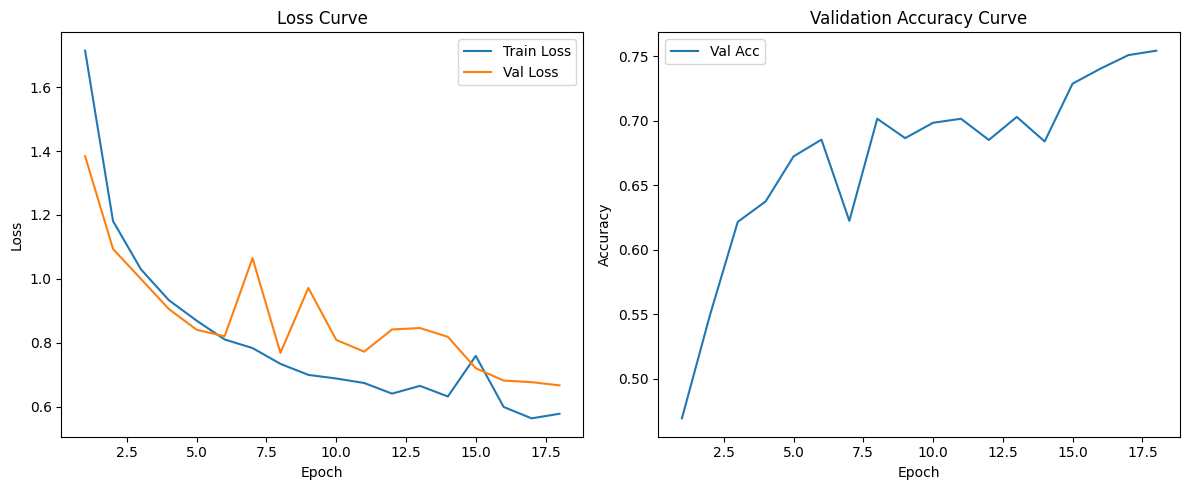

Test Loss: 0.6444, Test Accuracy: 0.7597
Test Set Confusion Matrix:
[[304  19   6  14  40]
 [ 18 226  43  11  34]
 [  2  23 351   2  21]
 [ 67  25  10 134  42]
 [ 22  19  14  15 398]]


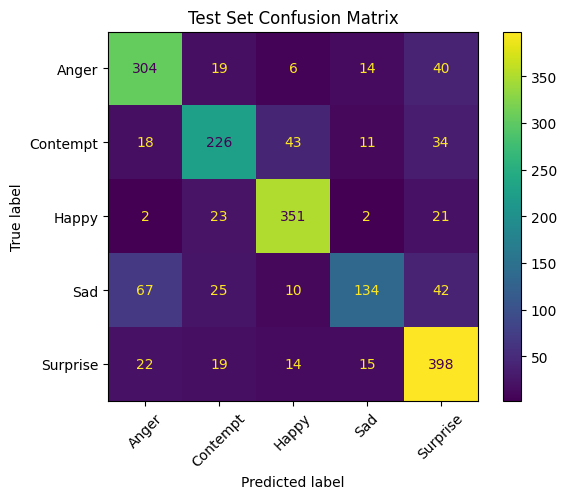

In [24]:
# 5. 绘制训练和验证损失曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_loss_list, label='Train Loss')
if val_loss_list: # Only plot if val_loss was recorded
    plt.plot(range(1, epochs + 1), val_loss_list, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_acc_list, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

# 6. 对测试集进行预测并生成混淆矩阵
test_acc, test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss if test_loss is not None else 'N/A':.4f}, Test Accuracy: {test_acc:.4f}")

# 针对测试集的混淆矩阵
cm_test = confusion_matrix(test_labels, test_preds)
print("Test Set Confusion Matrix:")
print(cm_test)
if hasattr(train_dataset, 'classes') and train_dataset.classes: # Assuming test set has same classes
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=train_dataset.classes)
    disp_test.plot(xticks_rotation=45)
    plt.title("Test Set Confusion Matrix")
    plt.show()
else:
    print("类名不可用于生成测试集的混淆矩阵")


### 使用保存的模型进行预测

In [ ]:
# import paddle
# import numpy as np
# from paddle.vision import transforms
# from PIL import Image
# from paddle.vision.datasets import DatasetFolder
# import paddle.nn as nn

# import warnings # 导入 warnings 模块
# # 忽略特定的 UserWarning
# warnings.filterwarnings("ignore", message="UserWarning: Skip loading for layer1.1.conv1.weight. layer1.1.conv1.weight is not found in the provided dict.")

# # Specify random seed
# seed = 42
# paddle.seed(seed)
# np.random.seed(seed)
# # Enable deterministic algorithms
# paddle.set_flags({'FLAGS_cudnn_deterministic': True})
# paddle.set_flags({'FLAGS_benchmark': False})  # Disable benchmark mode


# # 1. 定义预处理流程（必须与训练时一致）
# class BasicBlock(nn.Layer): # 和训练时一样的定义
#     expansion = 1 
#     def __init__(self, in_channels, out_channels, stride=1, downsample=None):
#         super(BasicBlock, self).__init__()
#         self.conv1 = nn.Conv2D(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias_attr=False)
#         self.bn1 = nn.BatchNorm2D(out_channels)
#         self.relu = nn.ReLU()
#         self.conv2 = nn.Conv2D(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias_attr=False)
#         self.bn2 = nn.BatchNorm2D(out_channels)
#         self.downsample = downsample
#         self.stride = stride

#     def forward(self, x):
#         identity = x
#         out = self.conv1(x)
#         out = self.bn1(out)
#         out = self.relu(out)
#         out = self.conv2(out)
#         out = self.bn2(out)
#         if self.downsample is not None:
#             identity = self.downsample(x)
#         out += identity
#         out = self.relu(out)
#         return out

# class MySimpleResNet(nn.Layer): # 和训练时一样的定义
#     def __init__(self, block, layers_cfg, num_classes=5):
#         super(MySimpleResNet, self).__init__()
#         self.in_channels = 64
#         self.conv1 = nn.Conv2D(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias_attr=False)
#         self.bn1 = nn.BatchNorm2D(self.in_channels)
#         self.relu = nn.ReLU()
#         self.maxpool = nn.MaxPool2D(kernel_size=3, stride=2, padding=1)
#         self.layer1 = self._make_layer(block, 64, layers_cfg[0])
#         self.layer2 = self._make_layer(block, 128, layers_cfg[1], stride=2)
#         self.layer3 = self._make_layer(block, 256, layers_cfg[2], stride=2)
#         # self.layer4 = self._make_layer(block, 512, layers_cfg[3], stride=2) # 如果训练时有layer4，加载时也要有
        
#         # current_fc_in_features 根据最后一个实际使用的 _make_layer 的输出通道数确定
#         # 在您的 MySimpleResNet (layers_cfg=[1,1,1]) 中, layer3 输出 256 * block.expansion
#         current_fc_in_features = 256 * block.expansion 
#         self.avgpool = nn.AdaptiveAvgPool2D((1, 1))
#         self.fc = nn.Linear(current_fc_in_features, num_classes)

#     def _make_layer(self, block, out_channels, blocks_num, stride=1):
#         downsample = None
#         if stride != 1 or self.in_channels != out_channels * block.expansion:
#             downsample = nn.Sequential(
#                 nn.Conv2D(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias_attr=False),
#                 nn.BatchNorm2D(out_channels * block.expansion),
#             )
#         layers = []
#         layers.append(block(self.in_channels, out_channels, stride, downsample))
#         self.in_channels = out_channels * block.expansion
#         for _ in range(1, blocks_num):
#             layers.append(block(self.in_channels, out_channels))
#         return nn.Sequential(*layers)

#     def forward(self, x):
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.maxpool(x)
#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         # if hasattr(self, 'layer4'): # 如果训练时有layer4
#         #     x = self.layer4(x)
#         x = self.avgpool(x)
#         x = paddle.flatten(x, 1)
#         x = self.fc(x)
#         return x


In [30]:

# 2. 重新实例化模型，确保架构与保存时完全一致
# MySimpleResNet初始化时要与训练时一致
def load_model(model_path, num_classes=5):
    
    model = MySimpleResNet(BasicBlock, [3, 4, 6, 3], num_classes=5)
    params_path = model_path
    model_state_dict = paddle.load(params_path)
    model.set_state_dict(model_state_dict)
    model.eval()
    return model

# 3. 预测函数
def predict_emotion(model, image_path, transform, class_names):
    try:
        # 加载并预处理图像
        img = Image.open(image_path).convert('RGB')  # 确保转换为RGB
        img_tensor = transform(img).unsqueeze(0)  # 添加batch维度
        
        # 执行预测
        with paddle.no_grad():
            outputs = model(img_tensor)
            probs = paddle.nn.functional.softmax(outputs).numpy()[0]
            pred_class = np.argmax(probs)
        
        return {
            'class': class_names[pred_class],
            'confidence': float(probs[pred_class]),
            'probabilities': dict(zip(class_names, probs))
        }
    except Exception as e:
        print(f"预测失败: {str(e)}")
        return None


seed = 42
paddle.seed(seed)
np.random.seed(seed)
# 加载模型（假设与训练时类别顺序一致）
MODEL_PATH = 'ResNetMyself_emotion.pdparams'
model = load_model(MODEL_PATH)


# 假设的类别标签（与训练数据实际顺序一致）
train_dataset = DatasetFolder('./dataset/train', transform=transform)
CLASS_NAMES = train_dataset.classes  

model = model.to('gpu' if paddle.is_compiled_with_cuda() else 'cpu')

# 为了保障预测结果的确定性
paddle.set_flags({'FLAGS_cudnn_deterministic': True})
paddle.set_flags({'FLAGS_benchmark': False})
# print("第一层权重哈希:", hash(model.parameters()[0].numpy().tobytes()))

# file_name = r'predict\surprise.jpg'
# file_name = r'predict\happy.jpg'
file_name = r'predict\angry.jpg'
# file_name = r'predict\sad.jpg'
# file_name = r'predict\contempt.jpg'



# 预测时的transform（无随机性）
predict_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 进行预测
result = predict_emotion(
    model=model,
    image_path=file_name,
    transform=predict_transform,  # 用无随机性的transform
    class_names=CLASS_NAMES
)


if result:
    print(f"{file_name}\n预测结果: {result['class']} (置信度: {result['confidence']*100:.2f}%)")
    print("各类别概率:")
    for cls, prob in result['probabilities'].items():
        print(f"{cls}: {prob*100:.2f}%")

predict\angry.jpg
预测结果: Anger (置信度: 65.01%)
各类别概率:
Anger: 65.01%
Contempt: 7.79%
Happy: 5.23%
Sad: 16.09%
Surprise: 5.89%
